# 03 — Univariate Analysis

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 



## 1. Load Clean Dataset

### Dataset Overview

In [2]:
df = pd.read_csv('../data/processed/diabetes_cleaned.csv')

In [3]:
df.head().T

,0,1,2,3,4
Diabetes_binary,0.0,0.0,0.0,0.0,0.0
HighBP,1.0,0.0,1.0,1.0,1.0
HighChol,1.0,0.0,1.0,0.0,1.0
CholCheck,1.0,0.0,1.0,1.0,1.0
BMI,40.0,25.0,28.0,27.0,24.0
Smoker,1.0,1.0,0.0,0.0,0.0
Stroke,0.0,0.0,0.0,0.0,0.0
HeartDiseaseorAttack,0.0,0.0,0.0,0.0,0.0
PhysActivity,0.0,1.0,0.0,1.0,1.0
Fruits,0.0,0.0,1.0,1.0,1.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 229474 entries, 0 to 229473
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       229474 non-null  float64
 1   HighBP                229474 non-null  float64
 2   HighChol              229474 non-null  float64
 3   CholCheck             229474 non-null  float64
 4   BMI                   229474 non-null  float64
 5   Smoker                229474 non-null  float64
 6   Stroke                229474 non-null  float64
 7   HeartDiseaseorAttack  229474 non-null  float64
 8   PhysActivity          229474 non-null  float64
 9   Fruits                229474 non-null  float64
 10  Veggies               229474 non-null  float64
 11  HvyAlcoholConsump     229474 non-null  float64
 12  AnyHealthcare         229474 non-null  float64
 13  NoDocbcCost           229474 non-null  float64
 14  GenHlth               229474 non-null  float64
 15  MentHlth   


## 2. Target Analysis


In [5]:
target = df.Diabetes_binary
target

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
229469    0.0
229470    1.0
229471    0.0
229472    0.0
229473    1.0
Name: Diabetes_binary, Length: 229474, dtype: float64


### Target Class Distribution

In [6]:
target.value_counts()

Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64



### Target Class Proportions



In [7]:
target.value_counts(normalize=True)

Diabetes_binary
0.0    0.847055
1.0    0.152945
Name: proportion, dtype: float64

### Target Distribution Visualization



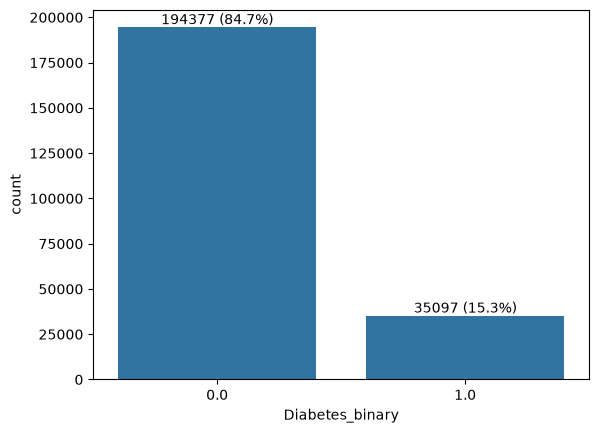

In [8]:
ax = sns.countplot(x=target)

total = len(target)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f'{v.get_height():.0f} ({v.get_height()/total:.1%})' for v in container]
    )

## 3. Numerical Features Analysis

In [9]:
numeric = df.BMI

In [10]:
pd.DataFrame(numeric)

,BMI
0,40.0
1,25.0
2,28.0
3,27.0
4,24.0
...,...
229469,45.0
229470,18.0
229471,28.0
229472,23.0


### Descriptive Statistics

In [11]:
numeric.describe()

count    229474.000000
mean         28.687507
std           6.789204
min          12.000000
25%          24.000000
50%          27.000000
75%          32.000000
max          98.000000
Name: BMI, dtype: float64

### Skewness Analysis

In [12]:
numeric.skew()

np.float64(2.0634752706475514)

### Distribution Visualization

<Axes: xlabel='BMI', ylabel='Count'>

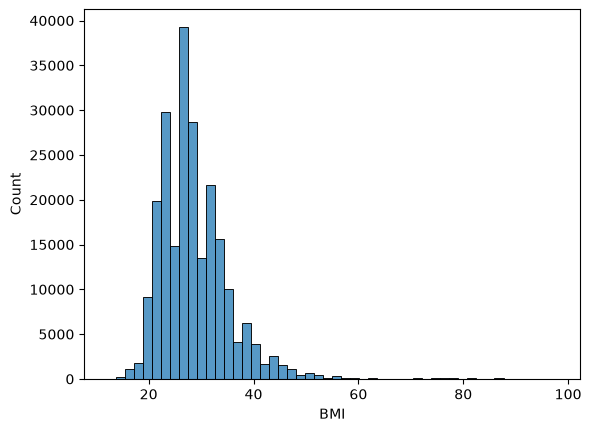

In [13]:
sns.histplot(data = numeric ,bins=50)

### Outlier Visualization

<Axes: ylabel='BMI'>

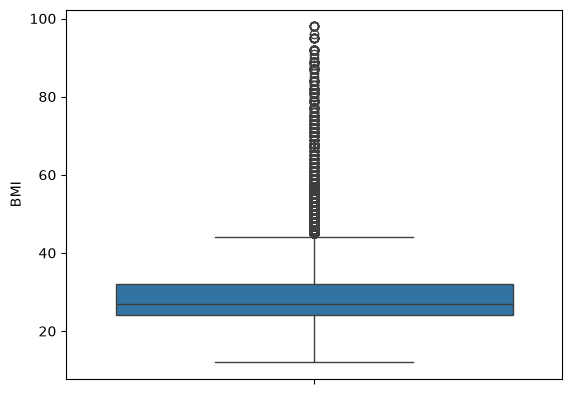

In [14]:
sns.boxplot(data = numeric)

## 4. Categorical / Ordinal Features Analysis

In [15]:
cats = df[["GenHlth", "Education", "Age", "Income"]]

In [16]:
cats

,GenHlth,Education,Age,Income
0,5.0,4.0,9.0,3.0
1,3.0,6.0,7.0,1.0
2,5.0,4.0,9.0,8.0
3,2.0,3.0,11.0,6.0
4,2.0,5.0,11.0,4.0
...,...,...,...,...
229469,3.0,6.0,5.0,7.0
229470,4.0,2.0,11.0,4.0
229471,1.0,5.0,2.0,2.0
229472,3.0,5.0,7.0,1.0


### GenHlth Distribution

In [17]:
print(f"col => GenHlth")
print(f"num of cats => {cats["GenHlth"].nunique()}\n")
print(f"cats => {cats["GenHlth"].unique()}\n")
print(f"nums of freq => {cats["GenHlth"].value_counts()}\n")
print(f"per or freq => {cats["GenHlth"].value_counts(normalize= True)*100} \n")

col => GenHlth
num of cats => 5

cats => [5. 3. 2. 4. 1.]

nums of freq => GenHlth
2.0    77365
3.0    73632
1.0    34854
4.0    31545
5.0    12078
Name: count, dtype: int64

per or freq => GenHlth
2.0    33.714059
3.0    32.087295
1.0    15.188649
4.0    13.746655
5.0     5.263341
Name: proportion, dtype: float64 



<Axes: xlabel='GenHlth', ylabel='count'>

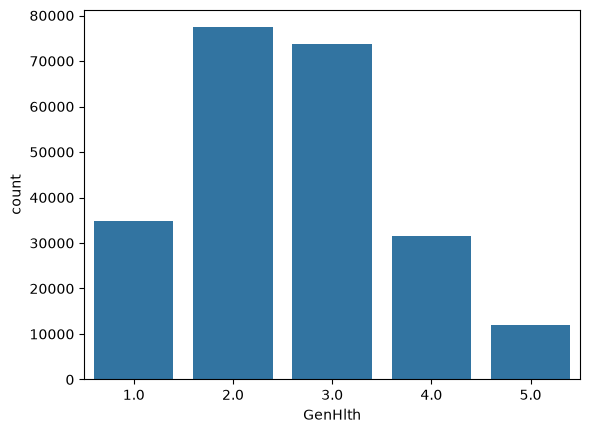

In [18]:
sns.countplot(data= cats, x='GenHlth')

### Education Distribution

In [19]:
print(f"col => Education")
print(f"num of cats => {cats["Education"].nunique()}\n")
print(f"cats => {cats["Education"].unique()}\n")
print(f"nums of freq => {cats["Education"].value_counts()}\n")
print(f"per or freq => {cats["Education"].value_counts(normalize= True)*100} \n")

col => Education
num of cats => 6

cats => [4. 6. 3. 5. 2. 1.]

nums of freq => Education
6.0    88225
5.0    66444
4.0    61124
3.0     9467
2.0     4040
1.0      174
Name: count, dtype: int64

per or freq => Education
6.0    38.446621
5.0    28.954914
4.0    26.636569
3.0     4.125522
2.0     1.760548
1.0     0.075826
Name: proportion, dtype: float64 



<Axes: xlabel='Education', ylabel='count'>

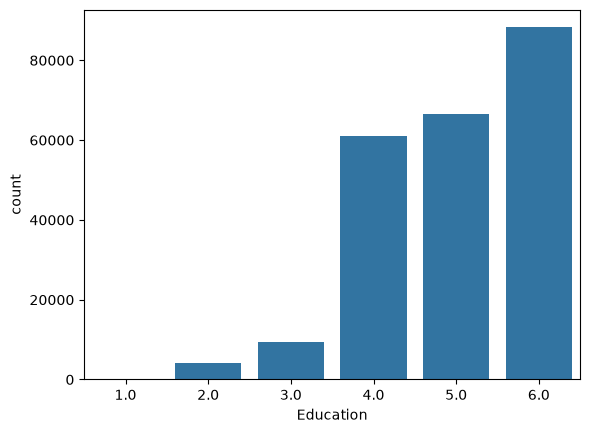

In [20]:
sns.countplot(data= cats, x='Education')

### Age Distribution

In [21]:
print(f"col => Age")
print(f"num of cats => {cats["Age"].nunique()}\n")
print(f"cats => {cats["Age"].unique()}\n")
print(f"nums of freq => {cats["Age"].value_counts()}\n")
print(f"per or freq => {cats["Age"].value_counts(normalize= True)*100} \n")

col => Age
num of cats => 13

cats => [ 9.  7. 11. 10.  8. 13.  4.  6.  2. 12.  5.  1.  3.]

nums of freq => Age
9.0     29678
10.0    29093
8.0     27272
7.0     23121
11.0    21993
6.0     17280
13.0    16791
12.0    15379
5.0     14040
4.0     12229
3.0     10023
2.0      7064
1.0      5511
Name: count, dtype: int64

per or freq => Age
9.0     12.933056
10.0    12.678125
8.0     11.884571
7.0     10.075651
11.0     9.584092
6.0      7.530265
13.0     7.317169
12.0     6.701849
5.0      6.118340
4.0      5.329144
3.0      4.367815
2.0      3.078344
1.0      2.401579
Name: proportion, dtype: float64 



<Axes: xlabel='Age', ylabel='count'>

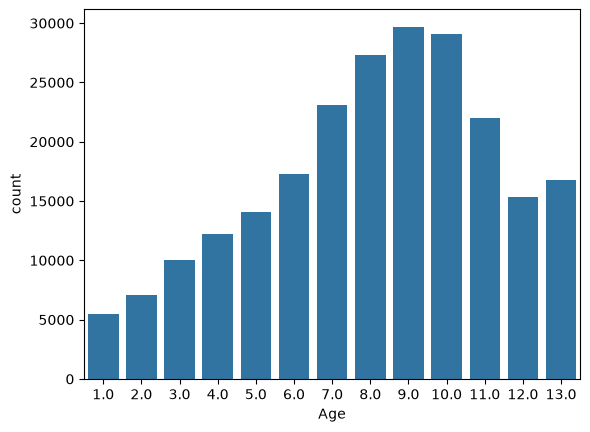

In [22]:
sns.countplot(data= cats, x='Age')

### Income Distribution

In [23]:
print(f"col => Income")
print(f"num of cats => {cats["Income"].nunique()}\n")
print(f"cats => {cats["Income"].unique()}\n")
print(f"nums of freq => {cats["Income"].value_counts()}\n")
print(f"per or freq => {cats["Income"].value_counts(normalize= True)*100} \n")

col => Income
num of cats => 8

cats => [3. 1. 8. 6. 4. 7. 2. 5.]

nums of freq => Income
8.0    71640
7.0    40131
6.0    34957
5.0    25326
4.0    19953
3.0    15920
2.0    11756
1.0     9791
Name: count, dtype: int64

per or freq => Income
8.0    31.219223
7.0    17.488256
6.0    15.233534
5.0    11.036544
4.0     8.695103
3.0     6.937605
2.0     5.123020
1.0     4.266714
Name: proportion, dtype: float64 



<Axes: xlabel='Income', ylabel='count'>

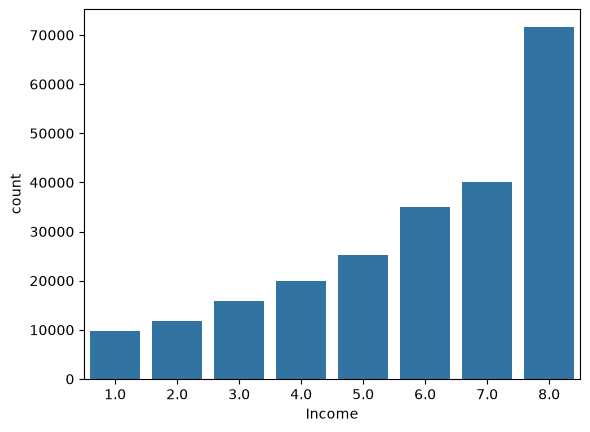

In [24]:
sns.countplot(data= cats, x='Income')

## 5. Binary Features Analysis

In [25]:
binary = df[['HighBP','HighChol','CholCheck','Smoker','Stroke',
             'HeartDiseaseorAttack','PhysActivity','Fruits',
             'Veggies','HvyAlcoholConsump','AnyHealthcare',
             'NoDocbcCost','DiffWalk','Sex']]
binary.head().T

,0,1,2,3,4
HighBP,1.0,0.0,1.0,1.0,1.0
HighChol,1.0,0.0,1.0,0.0,1.0
CholCheck,1.0,0.0,1.0,1.0,1.0
Smoker,1.0,1.0,0.0,0.0,0.0
Stroke,0.0,0.0,0.0,0.0,0.0
HeartDiseaseorAttack,0.0,0.0,0.0,0.0,0.0
PhysActivity,0.0,1.0,0.0,1.0,1.0
Fruits,0.0,0.0,1.0,1.0,1.0
Veggies,1.0,0.0,0.0,1.0,1.0
HvyAlcoholConsump,0.0,0.0,0.0,0.0,0.0


### Binary Features Proportions

In [26]:
for col in binary.columns :
    print(col ,"  ==> ",binary[col].nunique(),"cats\n",
          "    ",binary[col].value_counts(normalize= True),"\n")


HighBP   ==>  2 cats
      HighBP
0.0    0.545657
1.0    0.454343
Name: proportion, dtype: float64 

HighChol   ==>  2 cats
      HighChol
0.0    0.55836
1.0    0.44164
Name: proportion, dtype: float64 

CholCheck   ==>  2 cats
      CholCheck
1.0    0.959481
0.0    0.040519
Name: proportion, dtype: float64 

Smoker   ==>  2 cats
      Smoker
0.0    0.5342
1.0    0.4658
Name: proportion, dtype: float64 

Stroke   ==>  2 cats
      Stroke
0.0    0.955184
1.0    0.044816
Name: proportion, dtype: float64 

HeartDiseaseorAttack   ==>  2 cats
      HeartDiseaseorAttack
0.0    0.896664
1.0    0.103336
Name: proportion, dtype: float64 

PhysActivity   ==>  2 cats
      PhysActivity
1.0    0.733042
0.0    0.266958
Name: proportion, dtype: float64 

Fruits   ==>  2 cats
      Fruits
1.0    0.612675
0.0    0.387325
Name: proportion, dtype: float64 

Veggies   ==>  2 cats
      Veggies
1.0    0.794587
0.0    0.205413
Name: proportion, dtype: float64 

HvyAlcoholConsump   ==>  2 cats
      HvyAlco

### Binary Features Visualization

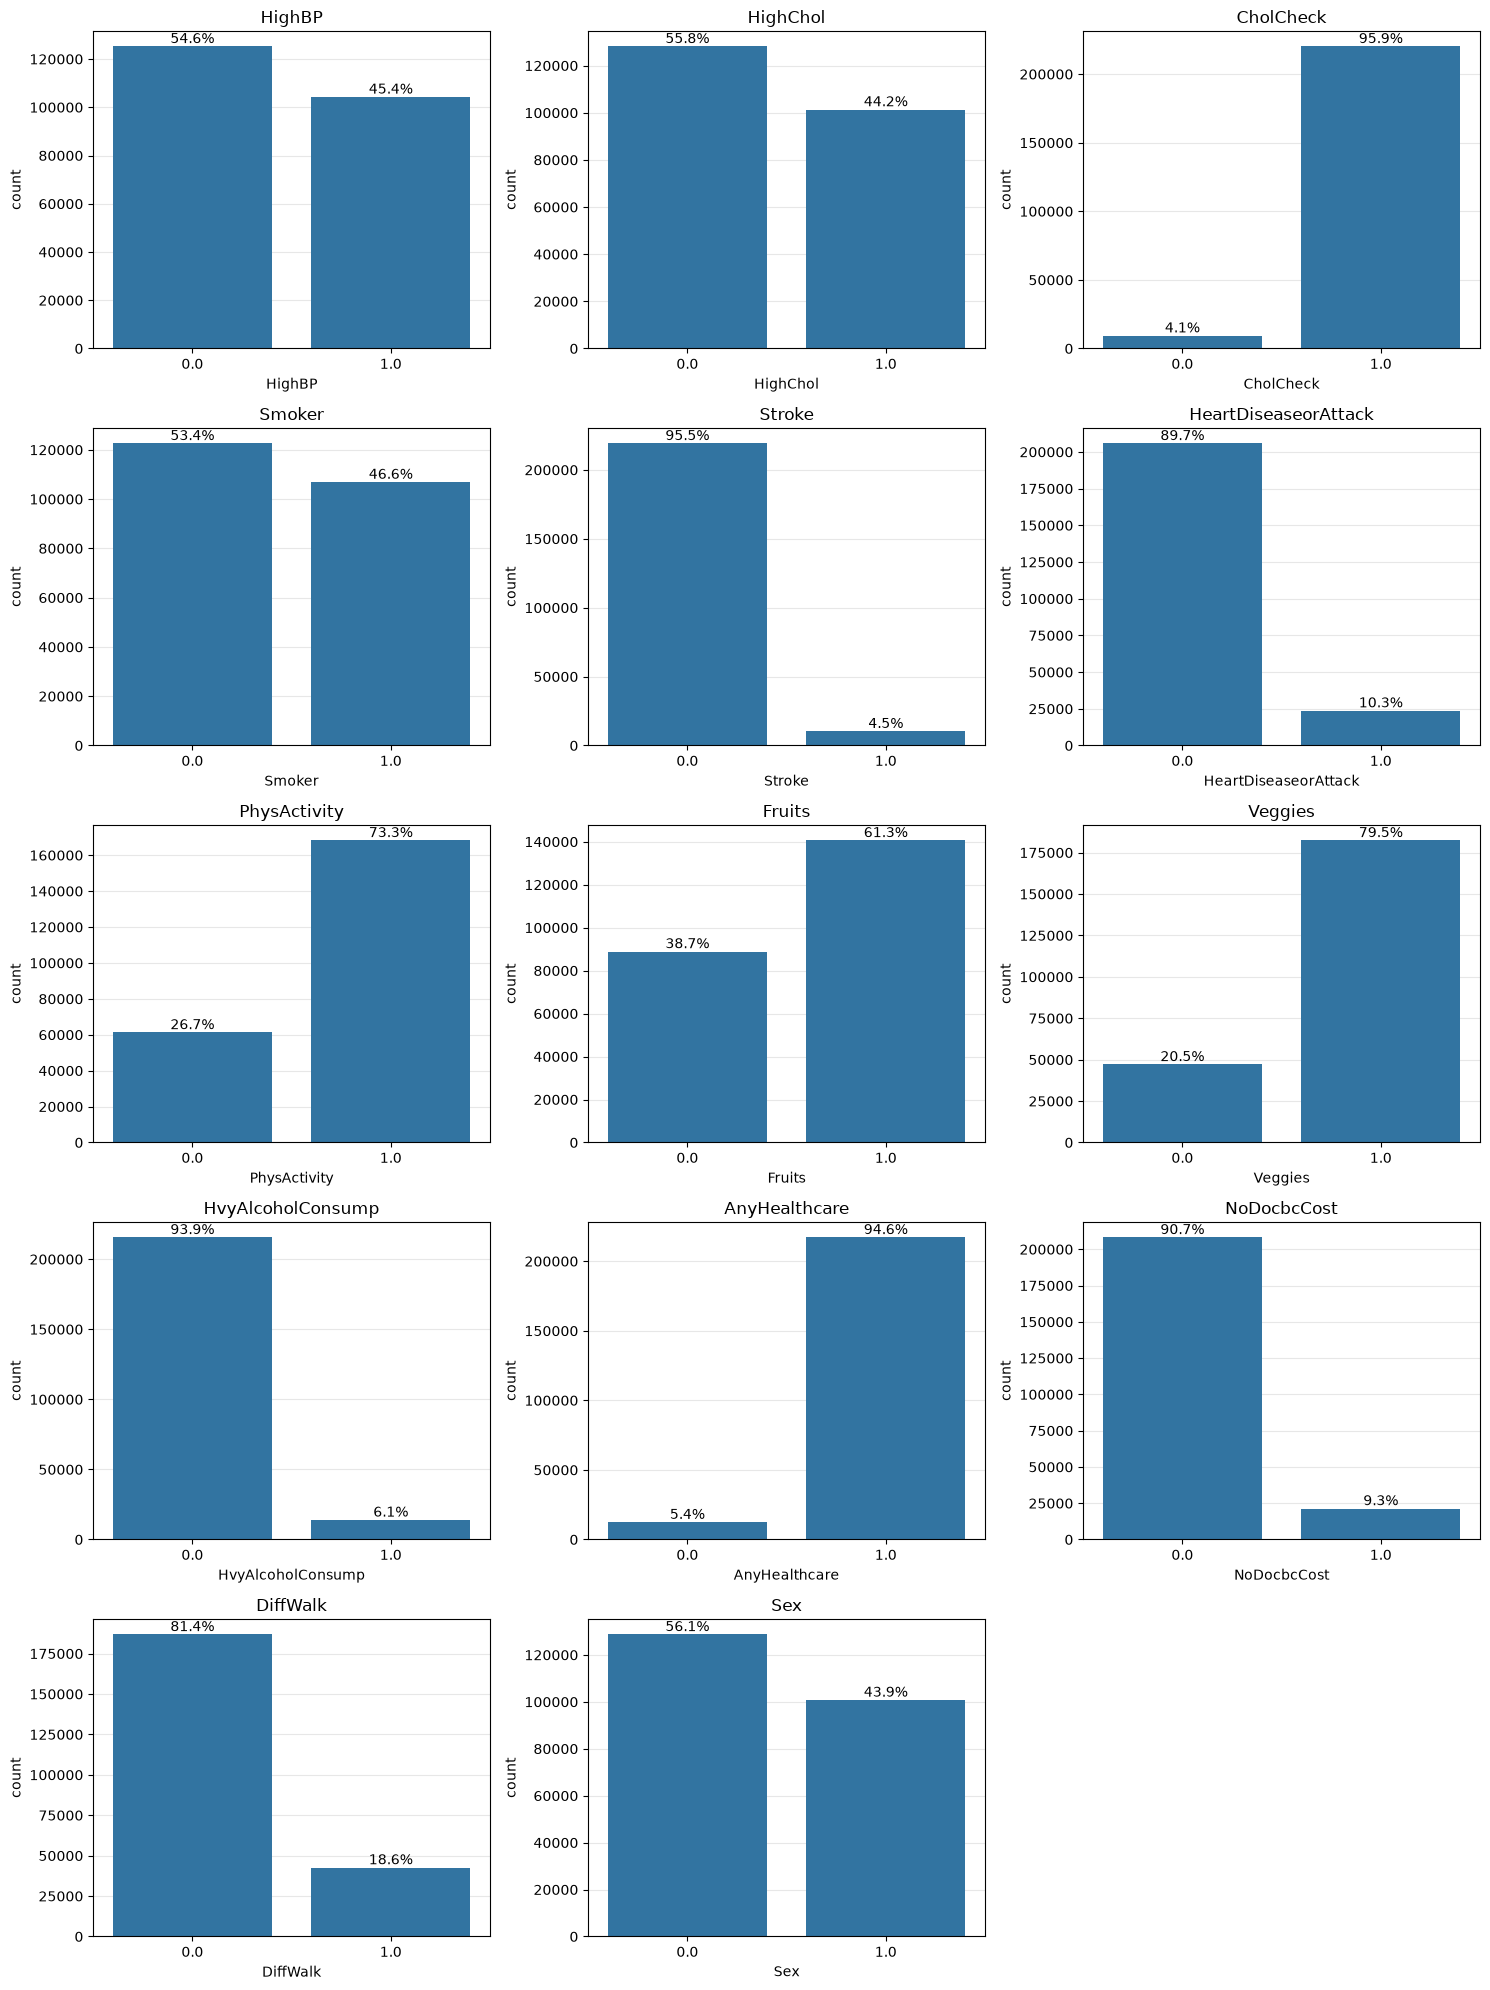

In [27]:
import math

cols = 3
rows = math.ceil(len(binary.columns) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(binary.columns):
    ax = sns.countplot(x=binary[col], ax=axes[i])

    total = len(binary[col])

    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f'{v.get_height()/total:.1%}' for v in container]
        )

    ax.set_title(col)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

for i in range(len(binary.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Univariate Findings

### Target
- The target variable is highly imbalanced, with approximately 84.7% of observations belonging to class 0 and 15.3% belonging to class 1.
- This class imbalance should be considered during the modeling stage and may require appropriate handling techniques.

### Numerical Features
- BMI is strongly right-skewed, supported by the positive skewness value (2.06), the difference between the mean (28.69) and median (27), and the histogram showing a long right tail.
- The majority of BMI values are concentrated in the lower-to-middle range, while a smaller number of observations extend to much higher values.
- Statistical outliers are present in BMI. Based on the previous investigation, these observations were retained because they may represent valid observations rather than data-entry errors.

### Categorical / Ordinal Features
- GenHlth contains five categories, with the majority of observations concentrated in categories 2 and 3.
- Education contains six categories, with most observations concentrated in the higher categories, particularly categories 4, 5, and 6.
- Age contains thirteen ordered categories, with categories 9 and 10 having the highest frequencies.
- Income contains eight ordered categories, with the frequency generally increasing across the categories and category 8 representing the largest group.

### Binary Features
- The binary features show different levels of class imbalance.
- HighBP, HighChol, Smoker, and Sex have relatively balanced distributions between their two classes.
- Several other binary features are strongly imbalanced, with one class representing the large majority of observations.
- The strongest imbalance is observed in features such as CholCheck, Stroke, HeartDiseaseorAttack, HvyAlcoholConsump, AnyHealthcare, and others.
- Fruits and Sex are among the relatively less imbalanced features compared with the strongly skewed binary variables.

### Overall Findings
- The dataset contains a highly imbalanced target variable.
- BMI has a clearly right-skewed distribution with statistical outliers that were retained after the previous investigation.
- The categorical and ordinal features are not uniformly distributed, with some categories representing substantially larger portions of the dataset.
- Most binary features are imbalanced to some degree, although a few features have relatively balanced class distributions.